# Anatomía del agente: qué entra, qué sale, qué se le dice al modelo

Este cuaderno abre la junta clínica por dentro sobre **un caso real** y la
sigue de principio a fin: los tres ficheros que entran, cómo se transforman en
las quince intervenciones, **qué prompt exacto vio el modelo de lenguaje en cada
turno y qué contestó**, qué tabla de variables construyó la sala, y los dos
ficheros que salen. Cierra con el diagrama de la arquitectura y con el análisis
agregado de las variables sobre los 195 casos.

Es el complemento de [`analisis_final.ipynb`](analisis_final.ipynb), que mide;
éste enseña. Los prompts se leen aquí tal como están en [`prompts.py`](../prompts.py),
con su análisis en [`PROMPTS.md`](../PROMPTS.md).

In [1]:
import json, sys, re, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 120)

REPO = Path.cwd()
while not (REPO / "src" / "chimera_agent_baseline").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
for p in (str(REPO), str(REPO / "src")):
    if p not in sys.path:
        sys.path.insert(0, p)

PKG = REPO / "delete_solution_one" / "solution_task_one_using_experts_final"
from delete_solution_one.solution_task_one_using_experts_final.analysis import report as R
from delete_solution_one.solution_task_one_using_experts_final import prompts as PR, protocol as P, decide as D, roster as RO
from delete_solution_one.solution_task_one_using_experts_final.board import Board
from delete_solution_one.solution_task_one_using_experts_final.experts import vocab as V

RUN = PKG / "runs" / "final"
run = R.load_run(RUN)
boards = R.load_boards(RUN)
gt, pay = R.ground_truth(), R.payloads()
S = {r["case_id"]: r for r in run["summary"] if r.get("ok")}

# El caso guía: uno etiquetado, con biopsia previa positiva (el cubo difícil) y
# con grado documentado en las notas, para que se vea el peldaño que lee documentos.
def _pick():
    for cid, r in S.items():
        if cid in gt and str(pay[cid].get("bx")) == "Positive" and r.get("grade") and cid in boards:
            return cid
    return next(iter(boards))
CASE = _pick()
b = boards[CASE]
print(f"corrida: {RUN.relative_to(REPO)} · {len(S)} casos entregados · caso guía: {CASE}")
print(f"  panel: PI-RADS {pay[CASE].get('pirads')} · PSA {pay[CASE].get('psa')} · PSAD {pay[CASE].get('psad')} · "
      f"edad {pay[CASE].get('age')} · biopsia previa {pay[CASE].get('bx')}")
print(f"  urólogo: {gt[CASE]['biopsy_decision']} — «{gt[CASE]['free_text'][:110]}»")
print(f"  entregado: {S[CASE]['decision']} · regla: {S[CASE]['protocol_rule']}")

corrida: delete_solution_one/solution_task_one_using_experts_final/runs/final · 195 casos entregados · caso guía: PT-pseudo_01b643727538
  panel: PI-RADS 5 · PSA 9.3 · PSAD 0.516 · edad 71 · biopsia previa Positive
  urólogo: no — «He has a ISUP3 cancer diagnosis already and he should be recommended treatment»
  entregado: no · regla: documented prior grade GG 3 (ISUP grade group 3)


---
# 1. La arquitectura

Una pizarra (Hearsay-II): un espacio común donde catorce participantes escriben
por turnos y nadie edita lo de otro. Tres tipos de participante, y el reparto es
la tesis de la solución:

* **código y expertos entrenados** (azul): leen el panel o los documentos ya
  abiertos y declaran, en el vocabulario del formulario, qué variables pesaron,
  a qué nivel y con qué confianza. Deciden el plan de documentos (Experto 4) y
  la decisión (protocolo);
* **modelo de lenguaje** (verde): recupera la guía, formula las preguntas, abre
  los documentos y reporta qué dicen, verifica, y redacta la nota clínica. **No
  vota**: sus votos se midieron en el azar en el cubo difícil;
* **herramientas MCP** (gris): los cinco documentos y la búsqueda en la guía.
  Lo que se abre es lo que se declara.

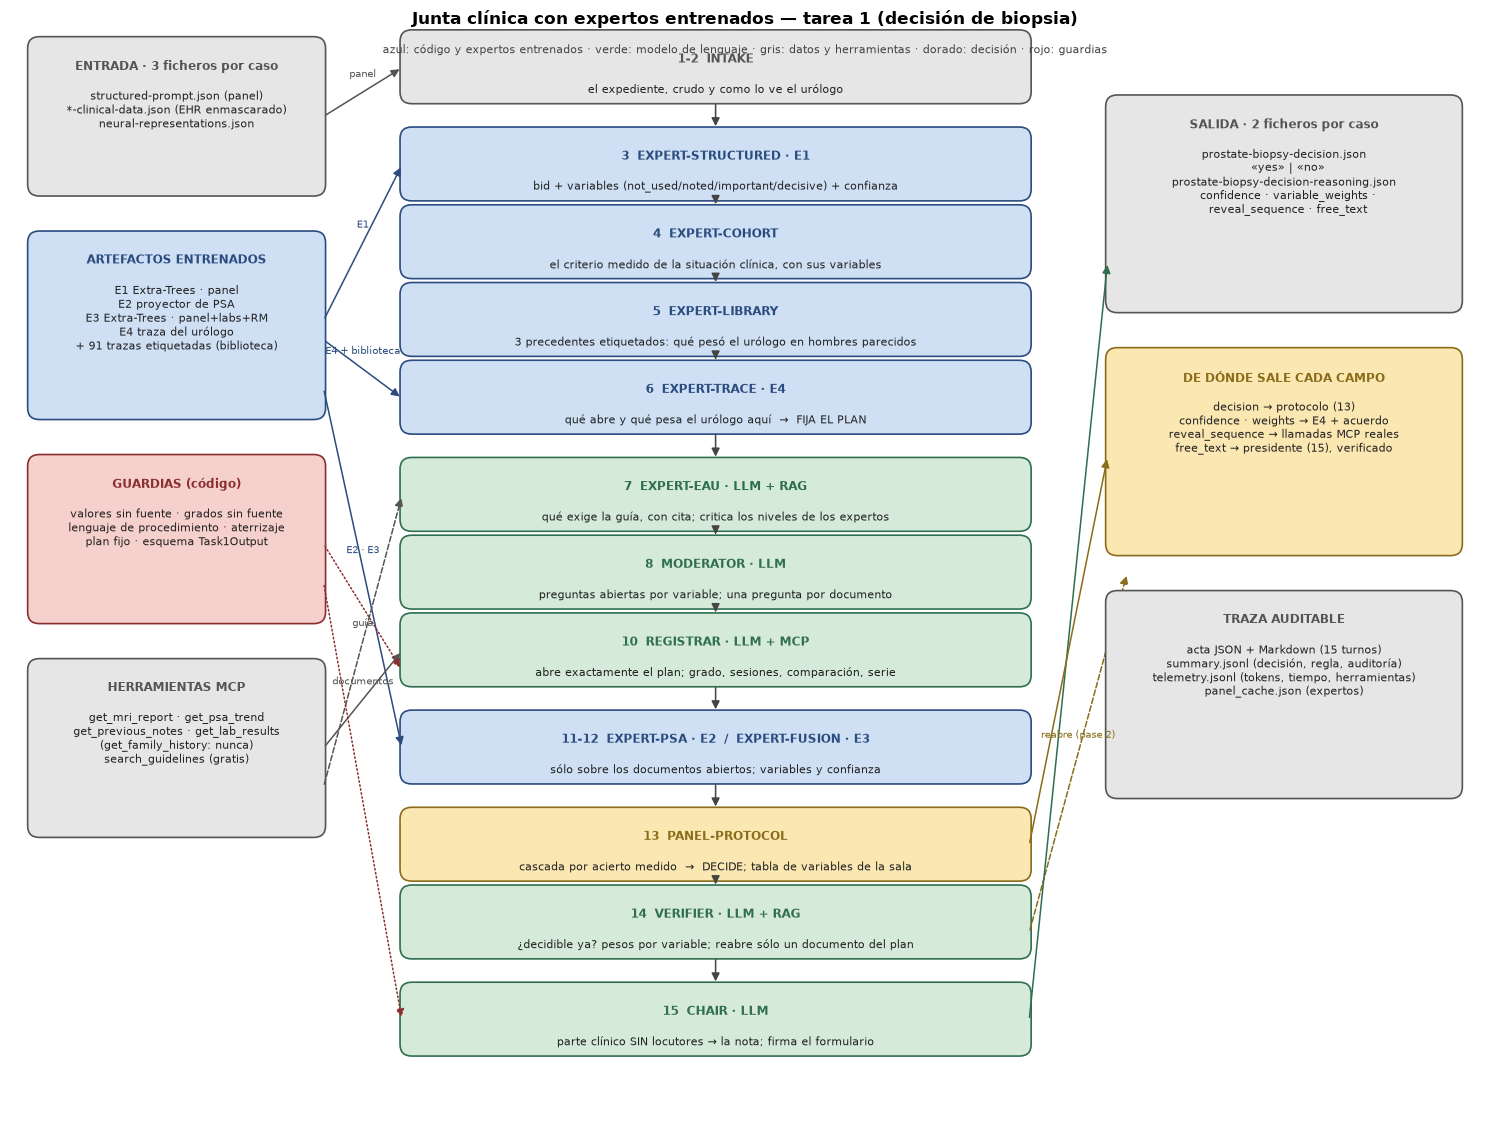

In [2]:
fig, ax = plt.subplots(figsize=(15, 11.5))
ax.set_xlim(0, 15); ax.set_ylim(0, 11.5); ax.axis("off")
BLUE, GREEN, GREY, GOLD, RED = "#cfe0f5", "#d5ead9", "#e6e6e6", "#fbe7b2", "#f6d0cc"
EDGE = {"#cfe0f5": "#2b4c7e", "#d5ead9": "#2f6f4f", "#e6e6e6": "#555", "#fbe7b2": "#8a6d1a", "#f6d0cc": "#8b2e2e"}

def box(x, y, w, h, text, color, fs=8.6, bold_first=True):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.12",
                                fc=color, ec=EDGE[color], lw=1.2))
    lines = text.split("\n")
    if bold_first:
        ax.text(x + w/2, y + h - 0.22, lines[0], ha="center", va="top", fontsize=fs+0.6, weight="bold", color=EDGE[color])
        rest = "\n".join(lines[1:])
        ax.text(x + w/2, y + h - 0.52, rest, ha="center", va="top", fontsize=fs, color="#222", linespacing=1.25)
    else:
        ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fs, color="#222", linespacing=1.25)

def arrow(x1, y1, x2, y2, text=None, color="#444", style="-|>", ls="-"):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle=style, mutation_scale=12, color=color, lw=1.1, ls=ls))
    if text:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.13, text, ha="center", va="bottom", fontsize=7.4, color=color)

# --- columna izquierda: entradas y artefactos ---------------------------------
box(0.2, 9.6, 3.0, 1.6, "ENTRADA · 3 ficheros por caso\nstructured-prompt.json (panel)\n*-clinical-data.json (EHR enmascarado)\nneural-representations.json", GREY, 8)
box(0.2, 7.3, 3.0, 1.9, "ARTEFACTOS ENTRENADOS\nE1 Extra-Trees · panel\nE2 proyector de PSA\nE3 Extra-Trees · panel+labs+RM\nE4 traza del urólogo\n+ 91 trazas etiquetadas (biblioteca)", BLUE, 8)
box(0.2, 5.2, 3.0, 1.7, "GUARDIAS (código)\nvalores sin fuente · grados sin fuente\nlenguaje de procedimiento · aterrizaje\nplan fijo · esquema Task1Output", RED, 8)
box(0.2, 3.0, 3.0, 1.8, "HERRAMIENTAS MCP\nget_mri_report · get_psa_trend\nget_previous_notes · get_lab_results\n(get_family_history: nunca)\nsearch_guidelines (gratis)", GREY, 8)

# --- columna central: las 15 intervenciones -------------------------------------
X, W = 4.0, 6.4
rows = [
    (10.55, "1-2  INTAKE", "el expediente, crudo y como lo ve el urólogo", GREY),
    (9.55, "3  EXPERT-STRUCTURED · E1", "bid + variables (not_used/noted/important/decisive) + confianza", BLUE),
    (8.75, "4  EXPERT-COHORT", "el criterio medido de la situación clínica, con sus variables", BLUE),
    (7.95, "5  EXPERT-LIBRARY", "3 precedentes etiquetados: qué pesó el urólogo en hombres parecidos", BLUE),
    (7.15, "6  EXPERT-TRACE · E4", "qué abre y qué pesa el urólogo aquí  →  FIJA EL PLAN", BLUE),
    (6.15, "7  EXPERT-EAU · LLM + RAG", "qué exige la guía, con cita; critica los niveles de los expertos", GREEN),
    (5.35, "8  MODERATOR · LLM", "preguntas abiertas por variable; una pregunta por documento", GREEN),
    (4.55, "10  REGISTRAR · LLM + MCP", "abre exactamente el plan; grado, sesiones, comparación, serie", GREEN),
    (3.55, "11-12  EXPERT-PSA · E2  /  EXPERT-FUSION · E3", "sólo sobre los documentos abiertos; variables y confianza", BLUE),
    (2.55, "13  PANEL-PROTOCOL", "cascada por acierto medido  →  DECIDE; tabla de variables de la sala", GOLD),
    (1.75, "14  VERIFIER · LLM + RAG", "¿decidible ya? pesos por variable; reabre sólo un documento del plan", GREEN),
    (0.75, "15  CHAIR · LLM", "parte clínico SIN locutores → la nota; firma el formulario", GREEN),
]
for y, head, sub, c in rows:
    box(X, y, W, 0.72, f"{head}\n{sub}", c, 8.2)
for i in range(len(rows) - 1):
    arrow(X + W/2, rows[i][0], X + W/2, rows[i+1][0] + 0.72)

# --- flechas de datos --------------------------------------------------------------
arrow(3.2, 10.4, X, 10.9, "panel", "#555")
arrow(3.2, 8.3, X, 9.9, "E1", "#2b4c7e"); arrow(3.2, 8.1, X, 7.5, "E4 + biblioteca", "#2b4c7e")
arrow(3.2, 7.6, X, 3.9, "E2 · E3", "#2b4c7e")
arrow(3.2, 3.9, X, 4.9, "documentos", "#555"); arrow(3.2, 3.5, X, 6.5, "guía", "#555", ls="--")
arrow(3.2, 6.0, X, 4.7, "", "#8b2e2e", ls=":"); arrow(3.2, 5.6, X, 1.1, "", "#8b2e2e", ls=":")
arrow(X + W, 2.0, 11.4, 5.7, "reabre (pase 2)", "#8a6d1a", ls="--")

# --- columna derecha: salidas y auditoría --------------------------------------
box(11.2, 8.4, 3.6, 2.2, "SALIDA · 2 ficheros por caso\nprostate-biopsy-decision.json\n  «yes» | «no»\nprostate-biopsy-decision-reasoning.json\n  confidence · variable_weights ·\n  reveal_sequence · free_text", GREY, 8)
box(11.2, 5.9, 3.6, 2.1, "DE DÓNDE SALE CADA CAMPO\ndecision → protocolo (13)\nconfidence · weights → E4 + acuerdo\nreveal_sequence → llamadas MCP reales\nfree_text → presidente (15), verificado", GOLD, 8)
box(11.2, 3.4, 3.6, 2.1, "TRAZA AUDITABLE\nacta JSON + Markdown (15 turnos)\nsummary.jsonl (decisión, regla, auditoría)\ntelemetry.jsonl (tokens, tiempo, herramientas)\npanel_cache.json (expertos)", GREY, 8)
arrow(X + W, 1.1, 11.2, 8.9, "", "#2f6f4f")
arrow(X + W, 2.9, 11.2, 6.9, "", "#8a6d1a")
ax.text(7.5, 11.35, "Junta clínica con expertos entrenados — tarea 1 (decisión de biopsia)", ha="center", fontsize=12, weight="bold")
ax.text(7.5, 11.05, "azul: código y expertos entrenados · verde: modelo de lenguaje · gris: datos y herramientas · dorado: decisión · rojo: guardias",
        ha="center", fontsize=8.2, color="#444")
plt.tight_layout(); plt.show()

In [3]:
# El mismo grafo, tal como LangGraph lo compila: los nodos reales, con los bucles
# de herramientas del EAU, del registrador y del verificador y la reapertura.
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import AIMessage
from langchain_core.outputs import ChatGeneration, ChatResult
from langchain_mcp_adapters.client import MultiServerMCPClient
from delete_solution_one.solution_task_one_using_experts_final.graph import create_conference_graph
from delete_solution_one.solution_task_one_using_experts_final.run_task1 import mcp_args

class _Mute(BaseChatModel):
    @property
    def _llm_type(self): return "mute"
    def bind_tools(self, tools, **kw): return self
    def _generate(self, messages, stop=None, run_manager=None, **kw):
        return ChatResult(generations=[ChatGeneration(message=AIMessage(content="{}"))])

client = MultiServerMCPClient({"chimera": {"command": sys.executable, "args": mcp_args(), "transport": "stdio"}})
tools = await client.get_tools()
g = create_conference_graph(tools, _Mute(), None, None, None)
print("herramientas MCP servidas:", [t.name for t in tools])
lg = g.get_graph()
print(f"{len(lg.nodes)} nodos · {len(lg.edges)} aristas\n")
try:
    # grandalf falla en el trazado de aristas de grafos con varios bucles
    # («no intersection found»); si pasa, se lista el grafo en vez de dibujarlo.
    print(lg.draw_ascii())
except Exception as exc:
    print(f"(el trazado ASCII de grandalf falló: {type(exc).__name__}; se listan las aristas)\n")
    for e in lg.edges:
        tag = f"  [{e.data}]" if getattr(e, "data", None) else ""
        print(f"  {e.source:22} -> {e.target}{tag}")

herramientas MCP servidas: ['get_psa_trend', 'get_lab_results', 'get_mri_report', 'get_previous_notes', 'get_family_history', 'search_guidelines']
30 nodos · 43 aristas

(el trazado ASCII de grandalf falló: ValueError; se listan las aristas)

  __start__              -> intake
  eau_agent              -> eau_nudge
  eau_agent              -> eau_post
  eau_agent              -> eau_tools
  eau_count              -> eau_agent
  eau_count              -> eau_finalize
  eau_finalize           -> eau_post
  eau_nudge              -> eau_nudge
  eau_nudge              -> eau_post
  eau_nudge              -> eau_tools
  eau_post               -> moderator
  eau_tools              -> eau_count
  expert_cohort          -> expert_library
  expert_fusion          -> panel_protocol
  expert_image           -> registrar_agent
  expert_library         -> expert_trace
  expert_psa             -> expert_fusion
  expert_structured      -> expert_cohort
  expert_trace           -> eau_agent
  intake   

In [4]:
# Y en Mermaid, por si se lee en VS Code o JupyterLab, que lo renderizan.
print(g.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	intake(intake)
	expert_structured(expert_structured)
	expert_cohort(expert_cohort)
	expert_library(expert_library)
	expert_trace(expert_trace)
	eau_agent(eau_agent)
	eau_count(eau_count)
	eau_nudge(eau_nudge)
	eau_finalize(eau_finalize)
	eau_post(eau_post)
	moderator(moderator)
	expert_image(expert_image)
	registrar_agent(registrar_agent)
	reg_count(reg_count)
	registrar_nudge(registrar_nudge)
	registrar_finalize(registrar_finalize)
	registrar_post(registrar_post)
	expert_psa(expert_psa)
	expert_fusion(expert_fusion)
	panel_protocol(panel_protocol)
	verifier_agent(verifier_agent)
	ver_count(ver_count)
	verifier_finalize(verifier_finalize)
	verifier_post(verifier_post)
	chair(chair)
	eau_tools(eau_tools)
	reg_tools(reg_tools)
	ver_tools(ver_tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> intake;
	eau_agent -.-> eau_nudge;
	eau_agent -.-> eau_post;
	eau_agent -.-> eau_tools;
	eau_coun

---
# 2. Qué entra

Tres ficheros por caso. El agente ve **directamente** sólo el primero; el
segundo llega por herramientas MCP y sólo lo que el plan pide; el tercero lo
lee el experto de imagen, que en esta tarea mide en el azar y sólo habla si lo
convocan.

In [5]:
case_dir = REPO / "data" / "task1" / "agent_input" / CASE
prompt_json = json.loads((case_dir / "structured-prompt.json").read_text())
clinical = json.loads((case_dir / "prostate-biopsy-decision-clinical-data.json").read_text())
feats = json.loads((case_dir / "prostate-modality-level-neural-representations.json").read_text())
print("=== structured-prompt.json — el panel (campos escalares; las secciones de texto se recortan)")
for k, v in prompt_json.items():
    if isinstance(v, (str, int, float)) and k not in ("notes",):
        print(f"   {k:20} {str(v)[:90]}")
print(f"   note_sections        {len(prompt_json.get('note_sections') or [])} apartados de la nota de encuentro")
print(f"\n=== prostate-biopsy-decision-clinical-data.json — el EHR extendido, enmascarado tras las herramientas")
for k, v in clinical.items():
    body = json.dumps(v, ensure_ascii=False)
    print(f"   {k:20} {len(body):6} caracteres   {body[:80]}…")
print(f"\n=== prostate-modality-level-neural-representations.json")
for k, v in feats.items():
    if isinstance(v, list):
        print(f"   {k:20} {len(v)} vector(es) de dimensión {len(v[0]) if v and isinstance(v[0], list) else '?'}")

=== structured-prompt.json — el panel (campos escalares; las secciones de texto se recortan)
   case_id              PT-pseudo_01b643727538
   pid                  PT-pseudo_01b643727538
   task                 1
   psa                  9.3
   age                  71
   months               1
   pirads               5
   psad                 0.516
   psav                 -0.41
   psap                 8.6
   vol                  18.03
   dre                  Normal
   bx                   Positive
   cspca                0.85247576
   medhx                Not reported
   meds                 None
   enc_dept             Urology - outpatient
   enc_date             23 Feb 2025
   enc_ref              Dr. F. de Boer (GP)
   enc_type             Re-evaluation - prior PCa diagnosis
   occupation           retired primary school teacher
   marital              Married
   living               Lives with partner
   next_of_kin          Spouse / partner (primary contact)
   alcohol             

In [6]:
# Lo que el urólogo lector ve antes de abrir nada — y lo que INTAKE lee en voz alta
# como intervención 2 — es el panel renderizado con la plantilla upstream.
from chimera_agent_baseline.case_loader import render_baseline_prompt
print(render_baseline_prompt(prompt_json, REPO / "templates" / "prompts"))

You are a senior urologist reviewing a patient case. The structured clinical
record below is shown to you up front, exactly as in the reading form. Some
documents are not shown and must be pulled up via the available tools
(radiology / MRI report, pathology report, previous notes, laboratory
results, PSA history, and the family-history anamnesis) when you need to
consult them.

Case ID: PT-pseudo_01b643727538
Task: 1

Encounter: Urology - outpatient on 23 Feb 2025.
Referrer: Dr. F. de Boer (GP).
Type: Re-evaluation - prior PCa diagnosis.

Clinical data (read-only — values loaded from the record):
  - 71-year-old male
  - PSA: 9.3 ng/mL
  - mpMRI — PI-RADS score: 5 (1–2 low · 3 equivocal · 4–5 high risk)
  - PSA density: 0.516 ng/mL²
  - PSA velocity: -0.41 ng/mL/yr
  - Prior PSA: 8.6 ng/mL
  - Prostate volume: 18.03 mL
  - Months since last PSA: 1
  - DRE findings: Normal (Normal · Nodus · Benign · Suspicious · Abnormal · Negative · Not done)
  - Prior biopsy: Positive (None · Negative

In [7]:
# Qué reciben los expertos entrenados de ese mismo caso: el panel precalculado.
from delete_solution_one.solution_task_one_using_experts_final.experts.panel import CACHE, Panel
panel = Panel(CACHE)
v = panel.verdicts(CASE, "deployed")
print("veredictos de los expertos para el caso guía (artefactos entrenados con los 91):")
for name in ("structured", "fusion_full", "fusion_nolab"):
    x = v[name]
    print(f"   {name:13} {x['decision']:3}  p={x['p']:.2f} ±{x['sigma']:.2f}  tramo={x['tier']:8} confianza={x['confidence']}")
print(f"   trace         abre {v['trace']['reveal_sequence']} · confianza {v['trace']['confidence']}")
print(f"   psa           {panel.projection(CASE)['direction']} ({panel.projection(CASE)['direction_confidence']})")
print("\nvariables que cada clasificador declara, en el vocabulario del formulario (importancia de permutación out-of-fold):")
for name in ("structured", "fusion"):
    w = panel.experts[name]["form_weights"]; sh = panel.experts[name]["variable_importance_share"]
    print(f"   {name:11} " + " · ".join(f"{k}={w[k]} ({sh[k]:.0%})" for k in V.VARIABLES if w[k] != "not_used"))

veredictos de los expertos para el caso guía (artefactos entrenados con los 91):
   structured    yes  p=0.52 ±0.18  tramo=discuss  confianza=uncertain
   fusion_full   no   p=0.41 ±0.19  tramo=discuss  confianza=uncertain
   fusion_nolab  yes  p=0.52 ±0.15  tramo=discuss  confianza=uncertain
   trace         abre ['radiology_report', 'psa_trend', 'laboratory_results', 'previous_notes'] · confianza clear
   psa           rising (borderline)

variables que cada clasificador declara, en el vocabulario del formulario (importancia de permutación out-of-fold):
   structured  bx=decisive (43%) · age=noted (2%) · dre=noted (10%) · psa=noted (3%) · vol=noted (1%) · psad=noted (0%) · cspca=noted (1%) · pirads=noted (20%) · comorbidity=important (21%)
   fusion      bx=decisive (43%) · dre=noted (5%) · psa=noted (21%) · vol=noted (4%) · psad=noted (0%) · pirads=important (22%) · comorbidity=noted (4%)


---
# 3. La sesión, turno a turno

Las quince intervenciones del caso guía. Para cada turno del modelo de lenguaje
se muestra **el prompt de sistema** (lo que define el papel), **el prompt de
usuario que vio en ese momento** (reconstruido desde el acta persistida, que es
exactamente lo que se le pasó) y **lo que contestó**. Para los turnos de código
se muestra lo que escribieron.

In [8]:
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(str(REPO / "model" / "gemma-4-E2B-it"))
ntok = lambda t: len(tok.encode(t, add_special_tokens=False))

def upto(n):
    # el acta tal como estaba justo antes de la intervención n
    return Board.from_dicts(CASE, 1, [i for i in b["interventions"] if i["n"] < n])

def show(title, text, limit=None):
    print("=" * 100); print(title); print("=" * 100)
    print(text if limit is None else text[:limit] + ("\n[…]" if len(text) > limit else "")); print()

items = {i["n"]: i for i in b["interventions"]}
by_speaker = defaultdict(list)
for i in b["interventions"]:
    by_speaker[i["speaker"]].append(i)
print(f"{b['n_interventions']} intervenciones; el acta completa pesa {ntok(Board.from_dicts(CASE, 1, b['interventions']).render()):,} tokens")
for i in b["interventions"]:
    print(f"  [{i['n']:2}] {i['speaker']:18} {ntok(i['body']):5} tokens · {(i.get('data') or {}).get('gist', '')[:80]}")

14 intervenciones; el acta completa pesa 7,506 tokens
  [ 1] INTAKE               964 tokens · record read out, field by field
  [ 2] INTAKE              1121 tokens · record as the reading form presents it
  [ 3] EXPERT-STRUCTURED    511 tokens · Expert 1 suggests BIOPSY, p=0.52 +/- 0.18, LOW reliability (discuss); weighs bx,
  [ 4] EXPERT-COHORT        377 tokens · cohort criterion abstains (prior positive biopsy): decided on the documented gra
  [ 5] EXPERT-LIBRARY       528 tokens · library precedent BIOPSY (p=1.00; uncertain)
  [ 6] EXPERT-TRACE         314 tokens · trace: opens radiology_report, psa_trend, previous_notes, laboratory_results; us
  [ 7] EXPERT-EAU           259 tokens · guideline reading
  [ 8] MODERATOR            248 tokens · plan: radiology_report, psa_trend, previous_notes, laboratory_results; 2 open qu
  [ 9] REGISTRAR            714 tokens · opened radiology_report, psa_trend, previous_notes, laboratory_results; leans bi
  [10] EXPERT-PSA           259 tokens

In [9]:
# 1-6: los turnos de código y de los expertos entrenados, íntegros.
for n in range(1, 7):
    it = items[n]
    show(f"INTERVENCIÓN {n} · {it['speaker']}", it["body"], limit=2600 if n <= 2 else None)

INTERVENCIÓN 1 · INTAKE
Colleagues, this is the record as it arrived, field by field. I read it out and interpret nothing; everything after this is yours.

{
  "case_id": "PT-pseudo_01b643727538",
  "pid": "PT-pseudo_01b643727538",
  "task": 1,
  "psa": 9.3,
  "age": 71,
  "months": 1,
  "pirads": "5",
  "psad": 0.516,
  "psav": -0.41,
  "psap": 8.6,
  "vol": 18.03,
  "dre": "Normal",
  "bx": "Positive",
  "cspca": 0.85247576,
  "medhx": "Not reported",
  "meds": "None",
  "notes": "PSA 9.3 ng/mL. PI-RADS 5. PSAD 0.52. Prostate volume 18 mL. csPCa 0.85.",
  "pmhx": [],
  "allergies": [],
  "vitals": {
    "weight": "86 kg",
    "height": "181 cm",
    "bmi": "26.3",
    "bp": "147/91 mmHg",
    "hr": "81 bpm",
    "smoking": "Non-smoker",
    "last_dental": "3 yr ago",
    "flu_vax": "Oct 2024"
  },
  "enc_dept": "Urology - outpatient",
  "enc_date": "23 Feb 2025",
  "enc_ref": "Dr. F. de Boer (GP)",
  "enc_type": "Re-evaluation - prior PCa diagnosis",
  "note_sections": [
    {
      

In [10]:
# 7 · EXPERT-EAU: el prompt de sistema, el prompt de usuario que vio, y su respuesta.
it = by_speaker["EXPERT-EAU"][0]
show(f"EXPERT-EAU · prompt de SISTEMA ({ntok(PR.EAU_SYSTEM):,} tokens)", PR.EAU_SYSTEM)
user = PR.eau_user(upto(it["n"]).render())
show(f"EXPERT-EAU · prompt de USUARIO ({ntok(user):,} tokens) — el acta hasta la intervención {it['n']-1} más la consigna; se muestra el final",
     user[-1500:])
show("EXPERT-EAU · RESPUESTA", it["body"])

EXPERT-EAU · prompt de SISTEMA (1,537 tokens)
You are one clinician in a live case conference about a single patient. The
minute of the conference is in front of you: everything your colleagues have
said so far, in order, each turn numbered. Whatever you say is appended to it
for the people who speak after you.

Who is in the room, in the order they speak:
  INTAKE             reads the record out loud. Interprets nothing.
  EXPERT-STRUCTURED  a trained classifier on the structured panel. An opening
                     bid with an error bar and a measured reliability tier.
  EXPERT-COHORT      the criterion the labelled series confirms for this exact
                     situation (prior-biopsy status, PI-RADS, PSA, age).
  EXPERT-LIBRARY     the closest labelled precedents, with what the reading
                     urologist decided and wrote for each of them.
  EXPERT-TRACE       a model of what the reading urologist opens and weighs in
                     this situation. Its list

In [11]:
# 8 · MODERATOR
it = by_speaker["MODERATOR"][0]
show(f"MODERATOR · prompt de SISTEMA ({ntok(PR.moderator_system('<catálogo>')):,} tokens)", PR.moderator_system("<el catálogo de documentos, generado desde la lista MCP viva>"))
planned = S[CASE].get("planned") or []
user = PR.moderator_user(upto(it["n"]).render(), 1, planned, [], None)
show(f"MODERATOR · prompt de USUARIO — sólo la consigna final (el acta va delante)", user[-900:])
show("MODERATOR · RESPUESTA (ya convertida en plan por el código)", it["body"])

MODERATOR · prompt de SISTEMA (1,335 tokens)
You are one clinician in a live case conference about a single patient. The
minute of the conference is in front of you: everything your colleagues have
said so far, in order, each turn numbered. Whatever you say is appended to it
for the people who speak after you.

Who is in the room, in the order they speak:
  INTAKE             reads the record out loud. Interprets nothing.
  EXPERT-STRUCTURED  a trained classifier on the structured panel. An opening
                     bid with an error bar and a measured reliability tier.
  EXPERT-COHORT      the criterion the labelled series confirms for this exact
                     situation (prior-biopsy status, PI-RADS, PSA, age).
  EXPERT-LIBRARY     the closest labelled precedents, with what the reading
                     urologist decided and wrote for each of them.
  EXPERT-TRACE       a model of what the reading urologist opens and weighs in
                     this situation. Its list 

In [12]:
# 10 · REGISTRAR: abre el plan y reporta. Su prompt de usuario lleva las preguntas del moderador.
it = by_speaker["REGISTRAR"][0]
show(f"REGISTRAR · prompt de SISTEMA ({ntok(PR.REGISTRAR_SYSTEM):,} tokens)", PR.REGISTRAR_SYSTEM)
plan = (by_speaker["MODERATOR"][0].get("data") or {}).get("plan") or []
show("REGISTRAR · prompt de USUARIO — la consigna con el plan (el acta va delante)", PR.registrar_user("", plan, 1))
show(f"REGISTRAR · RESPUESTA — abrió {it['data'].get('revealed')}", it["body"])
tele = [t for t in run["telemetry"] if t.get("kind") == "tool" and t.get("case_id") == CASE]
print("herramientas llamadas en este caso:", [(t["tool"], f"{t['seconds']}s", f"{t['tokens']} tok") for t in tele])

REGISTRAR · prompt de SISTEMA (1,546 tokens)
You are one clinician in a live case conference about a single patient. The
minute of the conference is in front of you: everything your colleagues have
said so far, in order, each turn numbered. Whatever you say is appended to it
for the people who speak after you.

Who is in the room, in the order they speak:
  INTAKE             reads the record out loud. Interprets nothing.
  EXPERT-STRUCTURED  a trained classifier on the structured panel. An opening
                     bid with an error bar and a measured reliability tier.
  EXPERT-COHORT      the criterion the labelled series confirms for this exact
                     situation (prior-biopsy status, PI-RADS, PSA, age).
  EXPERT-LIBRARY     the closest labelled precedents, with what the reading
                     urologist decided and wrote for each of them.
  EXPERT-TRACE       a model of what the reading urologist opens and weighs in
                     this situation. Its list 

In [13]:
# 11-13: los expertos que leen documentos, y el protocolo con la tabla de variables de la sala.
for sp in ("EXPERT-PSA", "EXPERT-FUSION", "PANEL-PROTOCOL"):
    for it in by_speaker.get(sp, []):
        show(f"INTERVENCIÓN {it['n']} · {sp}", it["body"])

INTERVENCIÓN 10 · EXPERT-PSA
Expert 2 here — the PSA projector. I read only the serial PSA the registrar opened.

TRAJECTORY: RISING (borderline). Last value 9.30 ng/mL over 3 points spanning 15 months; velocity +2.95 ng/mL per year; doubling time about 20 months.
PROJECTION at 6 months: 12.1 ng/mL, conformal 95% band 3.5-42.2.

Read the band before the point: it is wide by construction, and I only call a direction when the whole
band clears the last value. This does not vote on the biopsy — a rising PSA in a man with a known
diagnosis is the disease behaving as known — it tells the chair how fast the number is moving.

VARIABLES I WEIGHED — in the form's vocabulary, with this man's values (the serial PSA only)
  noted      PSA = 9.3 ng/mL
  not used   prior biopsy, family history, age, DRE, prostate volume, PSA density, csPCa probability, PI-RADS, comorbidity
CONFIDENCE: borderline — the conformal band does not clear the last value

INTERVENCIÓN 11 · EXPERT-FUSION
Expert 3 here — the 

In [14]:
# 14 · VERIFIER
it = by_speaker["VERIFIER"][0]
show(f"VERIFIER · prompt de SISTEMA ({ntok(PR.VERIFIER_SYSTEM):,} tokens)", PR.VERIFIER_SYSTEM)
qs = S[CASE].get("questions") or []
opened = S[CASE]["reveal_sequence"]
show("VERIFIER · prompt de USUARIO — la consigna (el acta va delante)",
     PR.verifier_user("", qs, opened, [s for s in planned if s not in opened], 1, 2))
show("VERIFIER · RESPUESTA", it["body"])

VERIFIER · prompt de SISTEMA (1,365 tokens)
You are one clinician in a live case conference about a single patient. The
minute of the conference is in front of you: everything your colleagues have
said so far, in order, each turn numbered. Whatever you say is appended to it
for the people who speak after you.

Who is in the room, in the order they speak:
  INTAKE             reads the record out loud. Interprets nothing.
  EXPERT-STRUCTURED  a trained classifier on the structured panel. An opening
                     bid with an error bar and a measured reliability tier.
  EXPERT-COHORT      the criterion the labelled series confirms for this exact
                     situation (prior-biopsy status, PI-RADS, PSA, age).
  EXPERT-LIBRARY     the closest labelled precedents, with what the reading
                     urologist decided and wrote for each of them.
  EXPERT-TRACE       a model of what the reading urologist opens and weighs in
                     this situation. Its list o

In [15]:
# 15 · CHAIR: NO ve el acta. Ve el parte clínico, reconstruido aquí desde el acta persistida.
it = by_speaker["CHAIR"][0]
show(f"CHAIR · prompt de SISTEMA ({ntok(PR.CHAIR_SYSTEM):,} tokens) — sin lista de participantes", PR.CHAIR_SYSTEM)
proto = by_speaker["PANEL-PROTOCOL"][-1]["data"]
reg_body = by_speaker["REGISTRAR"][-1]["body"]
grade = {"gg": S[CASE].get("grade"), "quote": S[CASE].get("grade_quote"), "on_surveillance": S[CASE].get("on_surveillance")}
because, against, alternative = P.clinical_reason(pay[CASE], grade, opened, proto["decision"])
found = re.split(r"WHAT I DID NOT OPEN|WHAT THIS SUPPORTS|WHERE THIS LEANS", reg_body.split("WHAT I FOUND", 1)[-1])[0].strip()
corpus = "\n".join(json.dumps(clinical[s], ensure_ascii=False) for s in opened if s in clinical)
found, _ = D.drop_unsourced_grade_lines(found, corpus)
eau_body = by_speaker["EXPERT-EAU"][0]["body"]
guideline = re.split(r"WHAT THE EXPERTS", eau_body.split("GUIDELINE", 1)[-1])[0].strip()
digest = PR.clinical_digest(pay[CASE], opened, found, grade, guideline, because, against, proto["decision"],
                            proto["confidence"], proto["variable_weights"], alternative, proto.get("variable_view"))
print(f"[el parte pesa {ntok(digest):,} tokens; el acta completa, {ntok(Board.from_dicts(CASE, 1, b['interventions']).render()):,}]\n")
from chimera_agent_baseline.output.schema import eligible_variables
elig = eligible_variables(1, set(RO.TOOL_BY_SECTION[s] for s in opened if s in RO.TOOL_BY_SECTION))
user = PR.chair_user(CASE, digest, pay[CASE], elig, PR.chair_skeleton(elig))
show(f"CHAIR · prompt de USUARIO ({ntok(user):,} tokens) — el parte clínico, el marco, tres notas reales del urólogo y el esqueleto", user)
show("CHAIR · RESPUESTA (turno en el acta)", it["body"])
print("auditoría del turno:", json.dumps(it["data"].get("audit"), ensure_ascii=False))

CHAIR · prompt de SISTEMA (1,080 tokens) — sin lista de participantes
You are the consultant urologist who signs this case. The work-up is finished:
the referral panel, the retrieved documents and the guideline reading are all in
front of you, and an assessment has been reached. You do two things and nothing
else: you sign the decision, and you write the note that goes in the record.

THE NOTE IS THE POINT. It is read and scored by another urologist, and it must
read like a line in a clinic list — the way a consultant writes when he has
thirty seconds and the next patient is waiting. Nothing about how the case was
worked up: no meetings, no discussions, no models, no rules, no reviewers, no
scores, no probabilities. Only this man, his numbers and what should happen to
him. If a reader could tell from your note that anything other than a doctor
looked at this patient, the note is wrong.

WHAT THE NOTE MUST DO, in two to four sentences:
  - state what he is, in the clinician's shorthand:

---
# 4. Qué sale

Dos ficheros, con el esquema del reto, y una traza. Abajo, el registro
entregado y la comparación con el urólogo lector.

In [16]:
out_dir = RUN / "output" / "task1" / CASE
dec = json.loads((out_dir / "prostate-biopsy-decision.json").read_text())
rea = json.loads((out_dir / "prostate-biopsy-decision-reasoning.json").read_text())
print("=== prostate-biopsy-decision.json"); print(json.dumps(dec))
print("\n=== prostate-biopsy-decision-reasoning.json"); print(json.dumps(rea, indent=2, ensure_ascii=False))
from chimera_agent_baseline.output.schema import Task1Output
Task1Output(case_id=CASE, task=1, biopsy_decision=dec == "yes", confidence=rea["confidence"],
            variable_weights=rea["variable_weights"], reveal_sequence=rea["reveal_sequence"], reasoning=rea["free_text"])
print("\nvalida contra Task1Output: sí")
print(f"\n=== el urólogo lector, mismo caso\n   decisión: {gt[CASE]['biopsy_decision']} · confianza: {gt[CASE]['confidence']}")
print(f"   pesos: {gt[CASE]['variable_weights']}\n   abrió: {gt[CASE]['reveal_sequence']}\n   escribió: «{gt[CASE]['free_text']}»")
ev = R.evaluator()
row = ev.evaluate_case({**gt[CASE]}, {**rea, "biopsy_decision": dec, "case_id": CASE}, None, None)
print(f"\n=== puntuación oficial de este caso: case_score {row['case_score']:.3f} · "
      + " · ".join(f"{k.replace('_score','')} {row[k]:.2f}" for k in R.COMPONENTS if row.get(k) is not None))

=== prostate-biopsy-decision.json
"no"

=== prostate-biopsy-decision-reasoning.json
{
  "confidence": "clear",
  "variable_weights": {
    "bx": "important",
    "fh": "not_used",
    "age": "important",
    "dre": "noted",
    "psa": "important",
    "vol": "noted",
    "psad": "noted",
    "cspca": "not_used",
    "pirads": "decisive",
    "comorbidity": "noted"
  },
  "reveal_sequence": [
    "radiology_report",
    "psa_trend",
    "previous_notes",
    "laboratory_results"
  ],
  "free_text": "71y male, PSA 9.3, PI-RADS 5, prior ISUP grade group 3 biopsy documented. Given prior tissue diagnosis, repeat biopsy is not indicated. The PI-RADS 5 finding is consistent with known cancer status, thus deferring biopsy. Staging and treatment planning is indicated."
}

valida contra Task1Output: sí

=== el urólogo lector, mismo caso
   decisión: no · confianza: clear
   pesos: {'age': 'important', 'fh': 'noted', 'cspca': 'not_used', 'pirads': 'important', 'vol': 'noted', 'psa': 'noted', 'com

In [17]:
# Coste de este caso, por papel: lo que la telemetría midió con el tokenizador del modelo.
llm = pd.DataFrame([t for t in run["telemetry"] if t.get("kind") == "llm" and t.get("case_id") == CASE])
display(llm.groupby("role").agg(llamadas=("role", "size"), tokens_entrada=("prompt_tokens", "sum"),
                                 tokens_salida=("completion_tokens", "sum"), segundos=("seconds", "sum")).round(2))
print(f"total: {S[CASE]['seconds']} s · {S[CASE]['tel_prompt_tokens']:,} tokens de entrada · {S[CASE]['tel_completion_tokens']:,} de salida")

,llamadas,tokens_entrada,tokens_salida,segundos
role,,,,
chair,1,2989,223,3.68
eau,2,12965,260,4.74
moderator,1,6081,201,2.91
registrar,2,13920,715,13.00
verifier,1,8463,357,5.12


total: 31.1 s · 44,418 tokens de entrada · 1,756 de salida


---
# 5. Las variables de la sala, sobre los 195 casos

Cada experto declara sus variables en el vocabulario del formulario. Aquí se
mide, sobre los 91 casos etiquetados, **cuánto se parece cada experto al
urólogo** en lo que marca como *important* o *decisive*, y cómo se reparte el
acuerdo del panel. Es el análisis que sostiene una decisión de diseño: subir
al formulario los pesos por acuerdo del panel **baja** la nota (0.8390 → 0.8365
medido), así que los pesos que se entregan siguen siendo los del Experto 4 y las
variables de los demás alimentan el razonamiento, no el formulario.

In [18]:
EXPERTS = ["EXPERT-STRUCTURED", "EXPERT-FUSION", "EXPERT-COHORT", "EXPERT-LIBRARY", "EXPERT-PSA"]
STRONG = ("important", "decisive")
rows = []
for cid, r in S.items():
    if cid not in gt or not r.get("variable_view"):
        continue
    for vv in r["variable_view"]:
        var = vv["variable"]
        g = gt[cid]["variable_weights"].get(var)
        rows.append({"case": cid, "variable": var, "urólogo": g in STRONG, "entregado": vv["record"] in STRONG,
                     "trace": vv["trace"] in STRONG,
                     **{e: (vv["levels"].get(e) in STRONG) for e in EXPERTS if e in vv["levels"]}})
df = pd.DataFrame(rows)
cols = [c for c in ["entregado", "trace"] + EXPERTS if c in df]
agree = df.groupby("variable")[cols + ["urólogo"]].mean().round(2)
print("fracción de casos etiquetados en que cada fuente marca la variable important/decisive (urólogo = referencia):")
display(agree)
match = pd.DataFrame({c: (df[c] == df["urólogo"]).groupby(df["variable"]).mean() for c in cols}).round(2)
print("\nacuerdo con el urólogo (misma clase important/decisive vs resto), por variable y fuente:")
display(match)
print("\nacuerdo medio con el urólogo:", match.mean().round(3).to_dict())

fracción de casos etiquetados en que cada fuente marca la variable important/decisive (urólogo = referencia):


,entregado,trace,EXPERT-STRUCTURED,EXPERT-FUSION,EXPERT-COHORT,EXPERT-LIBRARY,EXPERT-PSA,urólogo
variable,,,,,,,,
age,1.00,1.00,0.0,0.0,0.02,0.69,0.00,0.65
bx,0.67,0.67,1.0,1.0,1.00,0.69,0.00,0.70
comorbidity,0.00,0.00,1.0,0.0,0.00,0.08,0.00,0.08
cspca,0.00,0.00,0.0,0.0,0.00,0.08,0.00,0.12
dre,0.12,0.18,0.0,0.0,0.00,0.21,0.00,0.27
fh,0.00,0.00,0.0,0.0,0.00,0.04,0.00,0.03
pirads,1.00,1.00,0.0,1.0,0.48,0.99,0.00,0.99
psa,1.00,1.00,0.0,0.0,0.07,0.65,0.05,0.67
psad,0.00,0.00,0.0,0.0,0.00,0.30,0.00,0.33



acuerdo con el urólogo (misma clase important/decisive vs resto), por variable y fuente:


,entregado,trace,EXPERT-STRUCTURED,EXPERT-FUSION,EXPERT-COHORT,EXPERT-LIBRARY,EXPERT-PSA
variable,,,,,,,
age,0.65,0.65,0.35,0.35,0.37,0.54,0.35
bx,0.86,0.86,0.70,0.70,0.70,0.81,0.30
comorbidity,0.92,0.92,0.08,0.92,0.92,0.85,0.92
cspca,0.88,0.88,0.88,0.88,0.88,0.82,0.88
dre,0.78,0.81,0.73,0.73,0.73,0.69,0.73
fh,0.97,0.97,0.97,0.97,0.97,0.92,0.97
pirads,0.99,0.99,0.01,0.99,0.49,0.98,0.01
psa,0.67,0.67,0.33,0.33,0.40,0.60,0.38
psad,0.67,0.67,0.67,0.67,0.67,0.62,0.67



acuerdo medio con el urólogo: {'entregado': 0.819, 'trace': 0.822, 'EXPERT-STRUCTURED': 0.552, 'EXPERT-FUSION': 0.734, 'EXPERT-COHORT': 0.693, 'EXPERT-LIBRARY': 0.761, 'EXPERT-PSA': 0.601}


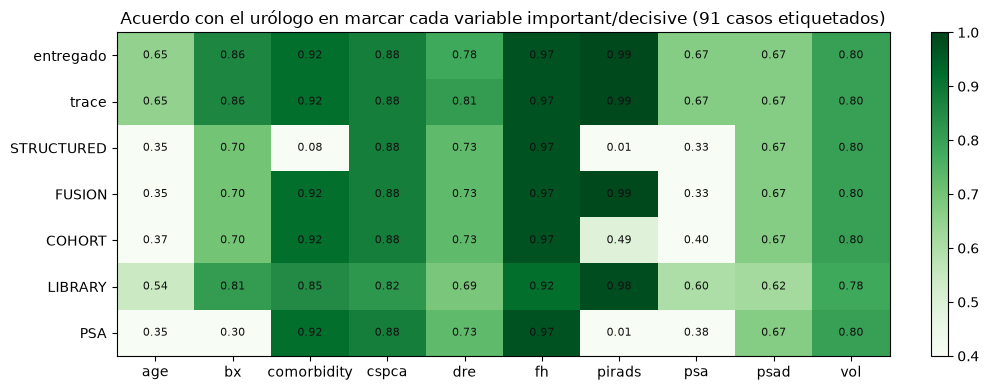

Lectura: el Experto 4 (trace) y lo entregado siguen al urólogo; los clasificadores discrepan en `bx` y
`comorbidity` porque miden lo que MOVIÓ su predicción, no lo que un urólogo marcaría. Es la divergencia
que la sala ve en cada acta, y la razón de que sus pesos no vayan al formulario.


In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
m = match.T
im = ax.imshow(m.values, cmap="Greens", vmin=0.4, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(m.columns))); ax.set_xticklabels(m.columns, rotation=0)
ax.set_yticks(range(len(m.index))); ax.set_yticklabels([i.replace("EXPERT-", "") for i in m.index])
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        ax.text(j, i, f"{m.values[i, j]:.2f}", ha="center", va="center", fontsize=8, color="#111")
ax.set_title("Acuerdo con el urólogo en marcar cada variable important/decisive (91 casos etiquetados)")
plt.colorbar(im, ax=ax, fraction=0.025); plt.tight_layout(); plt.show()
print("Lectura: el Experto 4 (trace) y lo entregado siguen al urólogo; los clasificadores discrepan en `bx` y")
print("`comorbidity` porque miden lo que MOVIÓ su predicción, no lo que un urólogo marcaría. Es la divergencia")
print("que la sala ve en cada acta, y la razón de que sus pesos no vayan al formulario.")

In [20]:
# La confianza que declara cada experto, frente a la del urólogo y a la entregada.
CM = {"clear": 2, "borderline": 1, "uncertain": 0}
rows = []
for cid, r in S.items():
    if cid not in gt or not r.get("expert_confidence"):
        continue
    for who, c in r["expert_confidence"].items():
        if c in CM:
            rows.append({"quién": who.replace("EXPERT-", ""), "distancia": abs(CM[c] - CM[gt[cid]["confidence"]]) / 2})
    rows.append({"quién": "ENTREGADO", "distancia": abs(CM[r["confidence"]] - CM[gt[cid]["confidence"]]) / 2})
cdf = pd.DataFrame(rows)
tab = (1 - cdf.groupby("quién")["distancia"].mean()).sort_values(ascending=False).round(3).rename("confidence_score que obtendría")
display(tab.to_frame())
print("Es el mismo cálculo que hace el evaluador oficial (1 − distancia ordinal / 2). La confianza entregada")
print("sale del acuerdo entre expertos y del tramo del que hablan, y es la que mejor sigue al urólogo.")

,confidence_score que obtendría
quién,
ENTREGADO,0.753
TRACE,0.736
COHORT,0.604
FUSION,0.604
STRUCTURED,0.599
PSA,0.571
LIBRARY,0.533


Es el mismo cálculo que hace el evaluador oficial (1 − distancia ordinal / 2). La confianza entregada
sale del acuerdo entre expertos y del tramo del que hablan, y es la que mejor sigue al urólogo.


In [21]:
# ¿La nota nombra las variables que el formulario registra como motores? Es la
# coherencia entre las dos mitades de la salida, y la razón de que el presidente
# reciba una lista corta y no la tabla entera: con la tabla delante bajaba.
PAT = {"pirads": r"PI-?RADS|\bP[2-5]\b", "psa": r"\bPSA\b(?!\s*densit|D)", "psad": r"PSAD|PSA densit",
       "bx": r"prior (positive |negative )?biops|biopsy-naive|ISUP|Gleason|surveillance",
       "age": r"\b\d{2}\s*(y|yo|y/o|-year)", "vol": r"volume|\bmL\b(?!/)", "dre": r"\bDRE\b|nodul|palpab",
       "comorbidity": r"comorbid|IPSS|LUTS", "cspca": r"csPCa", "fh": r"family histor"}
def prf(recs):
    rec, pre = [], []
    for r in recs:
        strong = {k for k, v in (r.get("variable_weights") or {}).items() if v in ("important", "decisive")}
        named = {k for k, pat in PAT.items() if re.search(pat, r.get("free_text") or "", re.I)}
        if strong:
            rec.append(len(strong & named) / len(strong))
        if named:
            pre.append(len(strong & named) / len(named))
    r_, p_ = float(np.mean(rec)), float(np.mean(pre))
    return {"recall": round(r_, 3), "precisión": round(p_, 3), "F1": round(2 * r_ * p_ / (r_ + p_), 3)}

filas = []
for label, root in (("nada (esta versión)", RUN),
                    ("la tabla entera", PKG / "runs" / "_v2_tabla_en_el_parte"),
                    ("sólo la lista de variables", PKG / "runs" / "_v3_lista_en_el_parte")):
    if (root / "summary.jsonl").exists():
        filas.append({"qué ve el presidente de la tabla": label,
                      **prf([r for r in R.load_run(root)["summary"] if r.get("ok")])})
display(pd.DataFrame(filas).set_index("qué ve el presidente de la tabla"))
print("Cuántas de las variables que el formulario registra como motores llega a nombrar la nota (recall), y")
print("cuántas de las que nombra están de verdad registradas (precisión). Las tres configuraciones dan la")
print("MISMA nota oficial —0.8390— porque el juez de razonamiento está apagado; lo que cambia es la nota.")
print("La dirección es consistente y contraintuitiva: darle al presidente la lista de variables no le ayuda")
print("a nombrarlas. La tabla vive en el acta y en el turno del verificador, que sí la usan.")

,recall,precisión,F1
qué ve el presidente de la tabla,,,
nada (esta versión),0.923,0.753,0.830
la tabla entera,0.890,0.760,0.820
sólo la lista de variables,0.900,0.733,0.808


Cuántas de las variables que el formulario registra como motores llega a nombrar la nota (recall), y
cuántas de las que nombra están de verdad registradas (precisión). Las tres configuraciones dan la
MISMA nota oficial —0.8390— porque el juez de razonamiento está apagado; lo que cambia es la nota.
La dirección es consistente y contraintuitiva: darle al presidente la lista de variables no le ayuda
a nombrarlas. La tabla vive en el acta y en el turno del verificador, que sí la usan.


In [22]:
# Cuántas variables pone la sala sobre la mesa, frente a las que el urólogo marca.
n_room = [sum(1 for vv in r["variable_view"] if vv["n_strong"] > 0) for r in S.values() if r.get("variable_view")]
n_uro = [sum(1 for v in g["variable_weights"].values() if v in STRONG) for g in gt.values()]
n_out = [sum(1 for v in r["variable_weights"].values() if v in STRONG) for r in S.values()]
print(f"variables marcadas important/decisive por AL MENOS un experto, por caso: media {np.mean(n_room):.1f}")
print(f"variables important/decisive en el formulario entregado, por caso:        media {np.mean(n_out):.1f}")
print(f"variables important/decisive que marca el urólogo, por caso:              media {np.mean(n_uro):.1f}")
print("\nLa sala discute más variables de las que se entregan; el formulario se ciñe a lo que el urólogo marca,")
print("que es lo que el evaluador compara.")

variables marcadas important/decisive por AL MENOS un experto, por caso: media 5.1
variables important/decisive en el formulario entregado, por caso:        media 3.9
variables important/decisive que marca el urólogo, por caso:              media 4.0

La sala discute más variables de las que se entregan; el formulario se ciñe a lo que el urólogo marca,
que es lo que el evaluador compara.


---
# 6. Los prompts, en cifras

Cada prompt de sistema con su coste y su cota. El análisis de cada uno —qué se
midió que hacía mal y qué se cambió— está en [`PROMPTS.md`](../PROMPTS.md).

In [23]:
filas = [("cabecera común (la ven EAU, moderador, registrador, verificador)", PR.CONFERENCE, "—"),
         ("EXPERT-EAU", PR.EAU_SYSTEM, "200 palabras; 1 búsqueda; una línea por documento"),
         ("MODERATOR", PR.MODERATOR_SYSTEM, "un JSON; preguntas por variable"),
         ("REGISTRAR", PR.REGISTRAR_SYSTEM, "320 palabras; llamar antes de escribir; líneas obligatorias"),
         ("VERIFIER", PR.VERIFIER_SYSTEM, "280 palabras; pesos por variable; línea VERDICT"),
         ("CHAIR", PR.CHAIR_SYSTEM, "40-90 palabras; sin acta ni nombres; lista negra")]
display(pd.DataFrame([{"prompt": a, "tokens": ntok(t), "palabras": len(t.split()), "cota": c} for a, t, c in filas]).set_index("prompt"))
print("Lo que el modelo ve por caso (media de la corrida):")
llm_all = pd.DataFrame([t for t in run["telemetry"] if t.get("kind") == "llm"])
n_cases = llm_all["case_id"].nunique()
display((llm_all.groupby("role")[["prompt_tokens", "completion_tokens"]].sum() / n_cases).round(0).astype(int)
        .rename(columns={"prompt_tokens": "tokens de entrada / caso", "completion_tokens": "tokens de salida / caso"}))

,tokens,palabras,cota
prompt,,,
"cabecera común (la ven EAU, moderador, registrador, verificador)",742,482,—
EXPERT-EAU,1537,1023,200 palabras; 1 búsqueda; una línea por documento
MODERATOR,1336,888,un JSON; preguntas por variable
REGISTRAR,1546,1050,320 palabras; llamar antes de escribir; líneas obligatorias
VERIFIER,1365,905,280 palabras; pesos por variable; línea VERDICT
CHAIR,1080,753,40-90 palabras; sin acta ni nombres; lista negra


Lo que el modelo ve por caso (media de la corrida):


,tokens de entrada / caso,tokens de salida / caso
role,,
chair,2659,230
eau,13055,370
moderator,6181,205
registrar,14961,393
verifier,8168,427
